## 留意事項

- 本資料は教育・情報提供を目的とした検証資料であり、特定の暗号資産や取引手法の売買を推奨するものではありません。
- バックテストは過去データに基づく試算であり、将来の成果を保証しません。
- 手数料、スリッページ、税、実際のETF Flow公表時刻を完全には再現していません。
- 特にETF Flowは、各日の最終値をその日のBTC終値時点で利用できたと仮定した結果を含みます。
- 実運用には、point-in-timeデータ、フォワードテスト、発注制御、リスク上限、停止条件の確認が必要です。

# 初心者botter会 〜米国・機関投資家の資金フロー判定〜

> **対象**: 裁量経験をベースに、AIでボット検証を始めたい方  
> **今回の問い**: BTCをロングしてよい市場環境で米国・機関投資家の資金フローから判定できるか  
> **主役のロジック**: `Market Score >= 1` のときだけBTCをロング<br>
> **現在の結論**: 仮説として有望。ただしETF Flowの公表時刻を反映した実行可能性は未確定

前回の先物乖離編では、次の開発テーマとしてCoinbase Premiumの再検証が候補になりました。今回はそこから、米国現物需要とETF資金フローを使ったBTCロング環境の判定へ進みます。

![botterkai](botterkai.jpeg)

### 配布ファイル

このNotebookは、同じフォルダにあるCSV 1ファイルだけを読み込みます。

- `BTC_ETF_market_score_event.ipynb`
- `flow_premium_score_event_data.csv`

全セルを上から実行すると、表とグラフを再計算します。

In [1]:
from pathlib import Path
import math
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
CSV_NAME = "flow_premium_score_event_data.csv"
CSV_CANDIDATES = [BASE / CSV_NAME, BASE / "event_notebook_etf_market_score" / CSV_NAME]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    tried = "\n".join(str(p) for p in CSV_CANDIDATES)
    raise FileNotFoundError(f"{CSV_NAME} が見つかりません。Notebookと同じフォルダに置いてください。\n{tried}")

# Running the Notebook may create this folder. It is not required in the ZIP.
OUT_DIR = BASE / "event_outputs_etf_market_score"
OUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 170
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["Hiragino Sans", "YuGothic", "Meiryo", "AppleGothic", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = [font]
        break

COLORS = {
    "HODL": "#171717",
    "Coinbase Premium > 0": "#2878b5",
    "ETF Flow > 0": "#2a9d45",
    "Market Score >= 1": "#8e44ad",
    "Market Score >= 1 (lag 1 observation)": "#d97706",
}

print("Input:", CSV_PATH.name)
print("Output folder:", OUT_DIR.name)

Input: flow_premium_score_event_data.csv
Output folder: event_outputs_etf_market_score


## 0. 今日の流れ

```text

BTCをロングしてよい環境を判定したい
↓
米国現物需要の代理としてCoinbase Premiumを検証
↓
2025年に単体効果が弱くなり、より直接的なETF Flowへ進む
↓
ETF Flow、Premium、Flow継続性、Fundingをスコア化
↓
HODLと比較
↓
利益の主因をETF FlowとPremiumに分解
↓
ETF Flow公表時刻を考えると、そのまま実運用できるのか
```

## 1. データを読み込む

固定された過去データを読み込みます。データ期間は2024年1月から2026年6月です。

主なデータソース:

- BTC価格: Binance USD-M Futures BTCUSDT 日足
- ETF Flow: The Block公開チャートの米国spot BTC ETF集計
- Coinbase Premium: Coinbase BTC-USDとBinance spot BTCUSDTの価格差
- Funding: Binance USD-M Futures funding history

In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["date"]).sort_values("date").set_index("date")

required = {
    "btc_close", "btc_daily_return", "is_etf_observation", "total_flow_usd",
    "premium_spot_bps", "premium_spot_ma24", "funding_rate_bps", "next_observation_return",
}
missing = sorted(required - set(df.columns))
if missing:
    raise ValueError(f"CSVに必要な列がありません: {missing}")

df["is_etf_observation"] = df["is_etf_observation"].astype(str).str.lower().eq("true")
obs = df.loc[df["is_etf_observation"]].copy()

print("Daily rows:", len(df))
print("ETF observation rows:", len(obs))
print("Period:", df.index.min().date(), "to", df.index.max().date())
display(df.head(3))

Daily rows: 889
ETF observation rows: 609
Period: 2024-01-11 to 2026-06-17


,btc_open,btc_high,btc_low,btc_close,btc_volume,btc_daily_return,total_flow_usd,total_flow_usd_ma5,premium_spot_bps,premium_spot_ma24,funding_rate_bps,next_observation_return,is_etf_observation
date,,,,,,,,,,,,,
2024-01-11 00:00:00+00:00,46663.0,49027.5,45600.0,46337.8,596698.379,NaN,655300000.0,655300000.0,0.755301,1.295817,1.0,-0.076588,True
2024-01-12 00:00:00+00:00,46337.9,46536.2,41370.0,42788.9,575943.258,-0.076588,203000000.0,429150000.0,-2.267270,-3.892802,1.0,0.008042,True
2024-01-13 00:00:00+00:00,42789.0,43273.4,42445.7,42846.4,207737.326,0.001344,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. 4つの指標で市場環境を採点する

### 1. Coinbase Premium

```text
(Coinbase BTC-USD / Binance spot BTCUSDT - 1) * 10,000
```

Coinbase側が相対的に高ければ、米国現物需要が強い可能性があると考えます。

### 2. ETF Flow

米国spot BTC ETF全体の純流入です。IBIT単体ではなく、ETF市場全体の現物需要を見ます。

### 3. ETF Flow 5観測日平均

5暦日ではなく、直近5回のETF報告値の平均です。単発ではなく、流入方向が継続しているかを見ます。

### 4. Funding

先物ロングが過熱していれば減点し、Fundingが大きくマイナスなら加点します。

In [3]:
# Recompute every score component inside the Notebook.
obs["total_flow_usd_ma5"] = obs["total_flow_usd"].rolling(5, min_periods=1).mean()
obs["premium_score"] = np.select(
    [obs["premium_spot_bps"] > 0, obs["premium_spot_bps"] < 0], [1, -1], default=0
)
obs["etf_flow_score"] = np.select(
    [obs["total_flow_usd"] > 0, obs["total_flow_usd"] < 0], [1, -1], default=0
)
obs["etf_persistence_score"] = np.select(
    [obs["total_flow_usd_ma5"] > 0, obs["total_flow_usd_ma5"] < 0], [1, -1], default=0
)
obs["funding_score"] = np.select(
    [obs["funding_rate_bps"] > 1.0, obs["funding_rate_bps"] < -0.5], [-1, 1], default=0
)
obs["score_raw"] = (
    obs["premium_score"] + obs["etf_flow_score"]
    + obs["etf_persistence_score"] + obs["funding_score"]
)
obs["market_score"] = obs["score_raw"].clip(-2, 2).astype(int)

score_spec = pd.DataFrame(
    [
        ["Coinbase Premium", "> 0: +1", "< 0: -1"],
        ["ETF Flow", "> 0: +1", "< 0: -1"],
        ["ETF Flow 5 observations MA", "> 0: +1", "< 0: -1"],
        ["Funding", "< -0.5 bps: +1", "> 1.0 bps: -1"],
    ],
    columns=["indicator", "positive", "negative"],
)
display(score_spec)
display(obs[["total_flow_usd", "premium_spot_bps", "funding_rate_bps", "market_score"]].tail())

,indicator,positive,negative
0,Coinbase Premium,> 0: +1,< 0: -1
1,ETF Flow,> 0: +1,< 0: -1
2,ETF Flow 5 observations MA,> 0: +1,< 0: -1
3,Funding,< -0.5 bps: +1,> 1.0 bps: -1


,total_flow_usd,premium_spot_bps,funding_rate_bps,market_score
date,,,,
2026-06-10 00:00:00+00:00,-213900000.0,-10.003091,0.2542,-2
2026-06-11 00:00:00+00:00,-22500000.0,-9.834032,0.2736,-2
2026-06-12 00:00:00+00:00,85900000.0,-6.539791,0.0840,-1
2026-06-15 00:00:00+00:00,-64800000.0,-7.830693,-0.6079,-2
2026-06-16 00:00:00+00:00,10200000.0,-8.887703,0.0246,-1


## 3. BTC価格とETF Flow

まずBTC価格とETF Flowを同じ日付軸で確認します。緑が純流入、赤が純流出です。

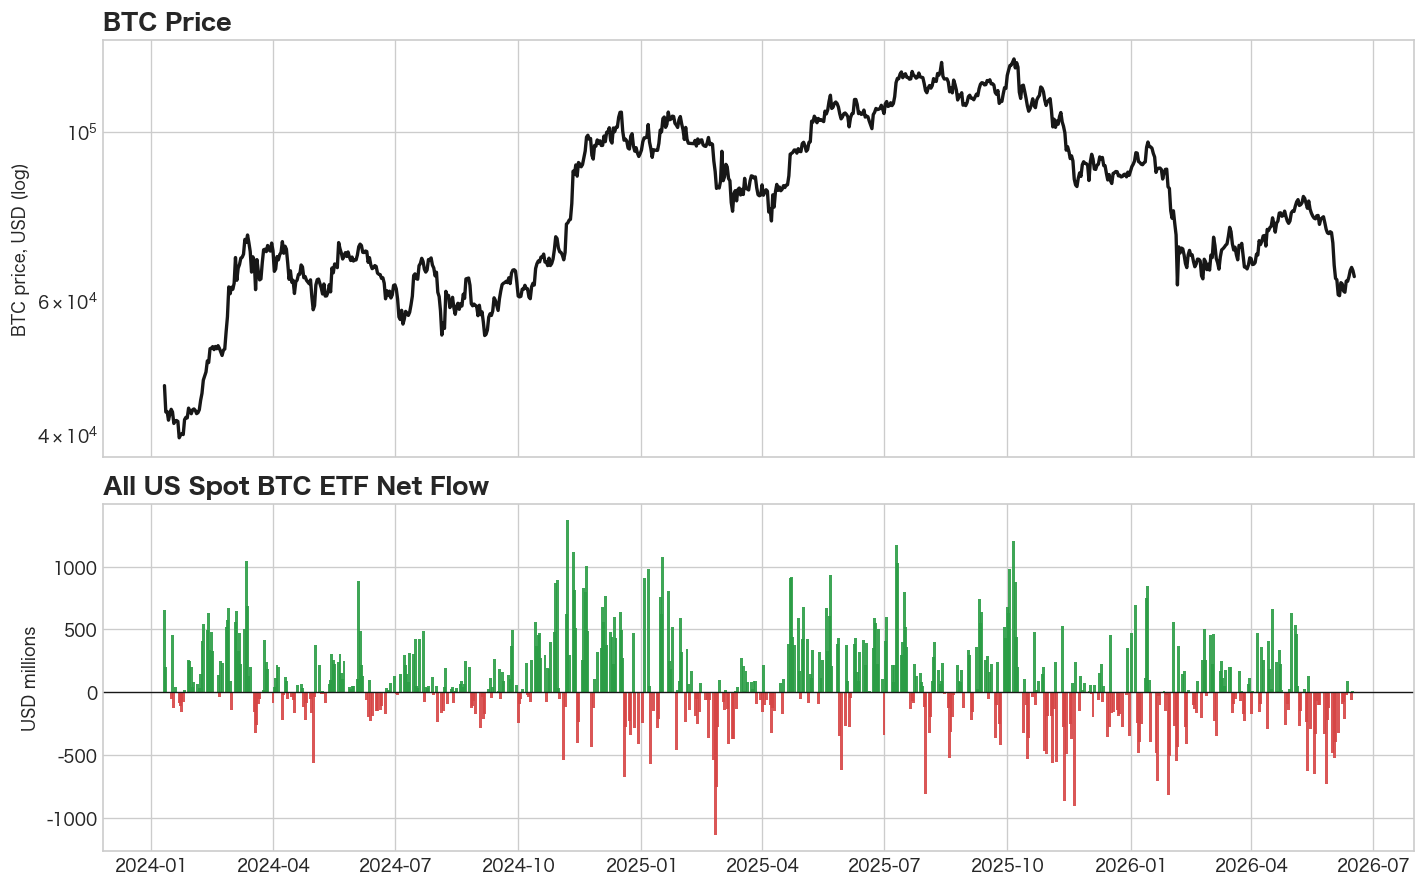

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"height_ratios": [1.2, 1.0]})

axes[0].plot(df.index, df["btc_close"], color="#171717", lw=2.0)
axes[0].set_yscale("log")
axes[0].set_title("BTC Price", loc="left", fontsize=14, fontweight="bold")
axes[0].set_ylabel("BTC price, USD (log)")

bar_colors = np.where(obs["total_flow_usd"] > 0, "#2a9d45", "#d64545")
axes[1].bar(obs.index, obs["total_flow_usd"] / 1e6, color=bar_colors, width=2.2, alpha=0.9)
axes[1].axhline(0, color="#171717", lw=0.8)
axes[1].set_title("All US Spot BTC ETF Net Flow", loc="left", fontsize=14, fontweight="bold")
axes[1].set_ylabel("USD millions")

fig.tight_layout()
fig.savefig(OUT_DIR / "01_btc_and_etf_flow.png", bbox_inches="tight")
plt.show()

* ETFへの資金流入が多い時期は、BTC価格も上昇する場面が見られました。
* ただし、このグラフだけでは因果関係までは証明できません。

## 4. スコアと次のETF観測区間リターン

スコアが高い観測日の後ほど次のETF観測日までのBTCリターンが高いかを確認します。

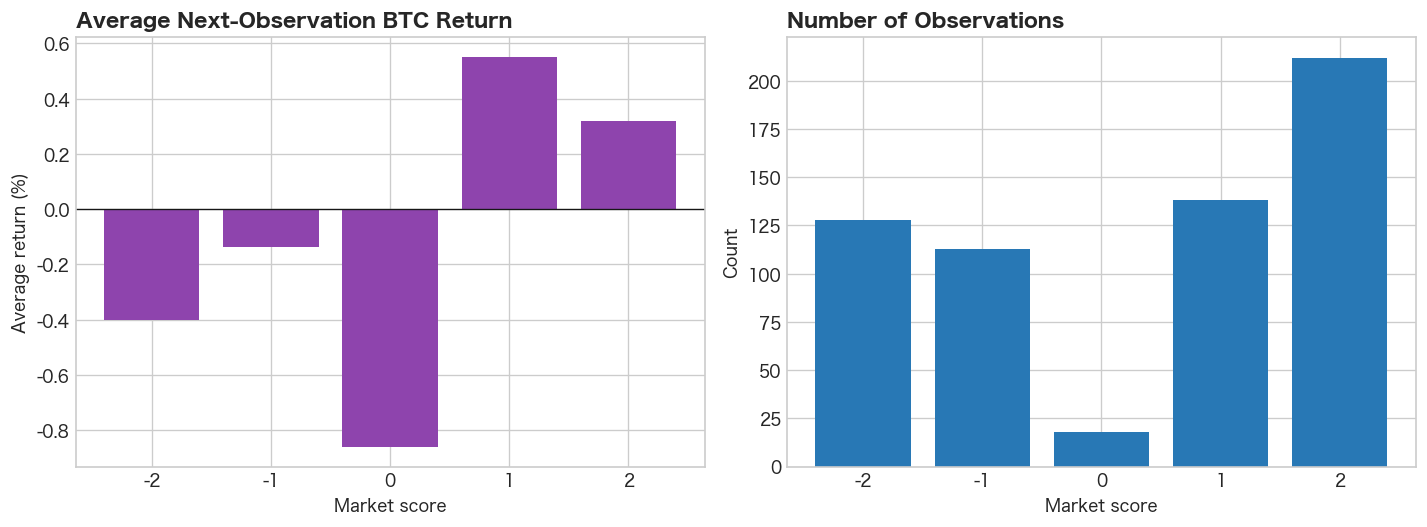

,count,mean_return_pct,win_rate_pct
market_score,,,
-2,128,-0.40,46.88
-1,113,-0.14,45.13
0,18,-0.86,38.89
1,138,0.55,49.28
2,212,0.32,55.66


In [5]:
score_forward = (
    obs.dropna(subset=["next_observation_return"])
    .groupby("market_score")["next_observation_return"]
    .agg(["count", "mean", lambda s: (s > 0).mean()])
    .rename(columns={"<lambda_0>": "win_rate"})
)
score_forward["mean_return_pct"] = score_forward["mean"] * 100
score_forward["win_rate_pct"] = score_forward["win_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(score_forward.index.astype(str), score_forward["mean_return_pct"], color="#8e44ad")
axes[0].axhline(0, color="#171717", lw=0.8)
axes[0].set_title("Average Next-Observation BTC Return", loc="left", fontweight="bold")
axes[0].set_xlabel("Market score")
axes[0].set_ylabel("Average return (%)")

axes[1].bar(score_forward.index.astype(str), score_forward["count"], color="#2878b5")
axes[1].set_title("Number of Observations", loc="left", fontweight="bold")
axes[1].set_xlabel("Market score")
axes[1].set_ylabel("Count")

fig.tight_layout()
fig.savefig(OUT_DIR / "02_forward_return_by_score.png", bbox_inches="tight")
plt.show()
display(score_forward[["count", "mean_return_pct", "win_rate_pct"]].round(2))

* スコアが1〜2のときは、その後のBTC平均リターンがプラスでした。
* 反対に、スコアが0以下では平均リターンがマイナスでした。

## 5. 売買ルール

主役は紫線の`Market Score >= 1`です。

```text
Score >= 1  → BTCロング
Score < 1   → キャッシュ（BTCを売り、何も仕掛けず現金で待機）
```

- ショートなし
- レバレッジなし
- 損切り・利確なし（価格の上昇率・下落率を理由に売らない）
- ETF Flow観測日に判定し、次の観測日まで状態を維持
- 日付`t`の情報を日付`t`のBTC終値時点で利用できたとする仮定

比較用としてHODL、Premium単体、ETF Flow単体も同じ条件で計算します。

In [6]:
observation_signals = pd.DataFrame(index=obs.index)
observation_signals["HODL"] = 1
observation_signals["Coinbase Premium > 0"] = (obs["premium_spot_bps"] > 0).astype(int)
observation_signals["ETF Flow > 0"] = (obs["total_flow_usd"] > 0).astype(int)
observation_signals["Market Score >= 1"] = (obs["market_score"] >= 1).astype(int)
observation_signals["Market Score >= 1 (lag 1 observation)"] = (
    observation_signals["Market Score >= 1"].shift(1).fillna(0)
)

# A signal observed at the close of day t applies from the next daily return onward.
daily_positions = pd.DataFrame(index=df.index)
daily_positions["HODL"] = 1.0
for name in observation_signals.columns.drop("HODL"):
    daily_positions[name] = observation_signals[name].reindex(df.index).ffill().shift(1).fillna(0.0)

daily_returns = daily_positions.mul(df["btc_daily_return"].fillna(0.0), axis=0)
daily_equity = (1.0 + daily_returns).cumprod()

print("Signal changes, Market Score:", int(daily_positions["Market Score >= 1"].diff().abs().fillna(0).sum()))
display(observation_signals.tail())

Signal changes, Market Score: 122


,HODL,Coinbase Premium > 0,ETF Flow > 0,Market Score >= 1,Market Score >= 1 (lag 1 observation)
date,,,,,
2026-06-10 00:00:00+00:00,1,0,0,0,0.0
2026-06-11 00:00:00+00:00,1,0,0,0,0.0
2026-06-12 00:00:00+00:00,1,0,1,0,0.0
2026-06-15 00:00:00+00:00,1,0,0,0,0.0
2026-06-16 00:00:00+00:00,1,0,1,0,0.0


* スコアが1以上の期間だけBTCを保有し、それ未満では現金で待機するルールです。
* 価格ではなく、スコアの変化だけで売買します。

## 6. HODLとの比較

対数軸ではなく、累積リターン%で表示します。

```text
+100% = 元本2倍
+200% = 元本3倍
```

下段は、元本100万円が最終的にいくらになったかを示します。

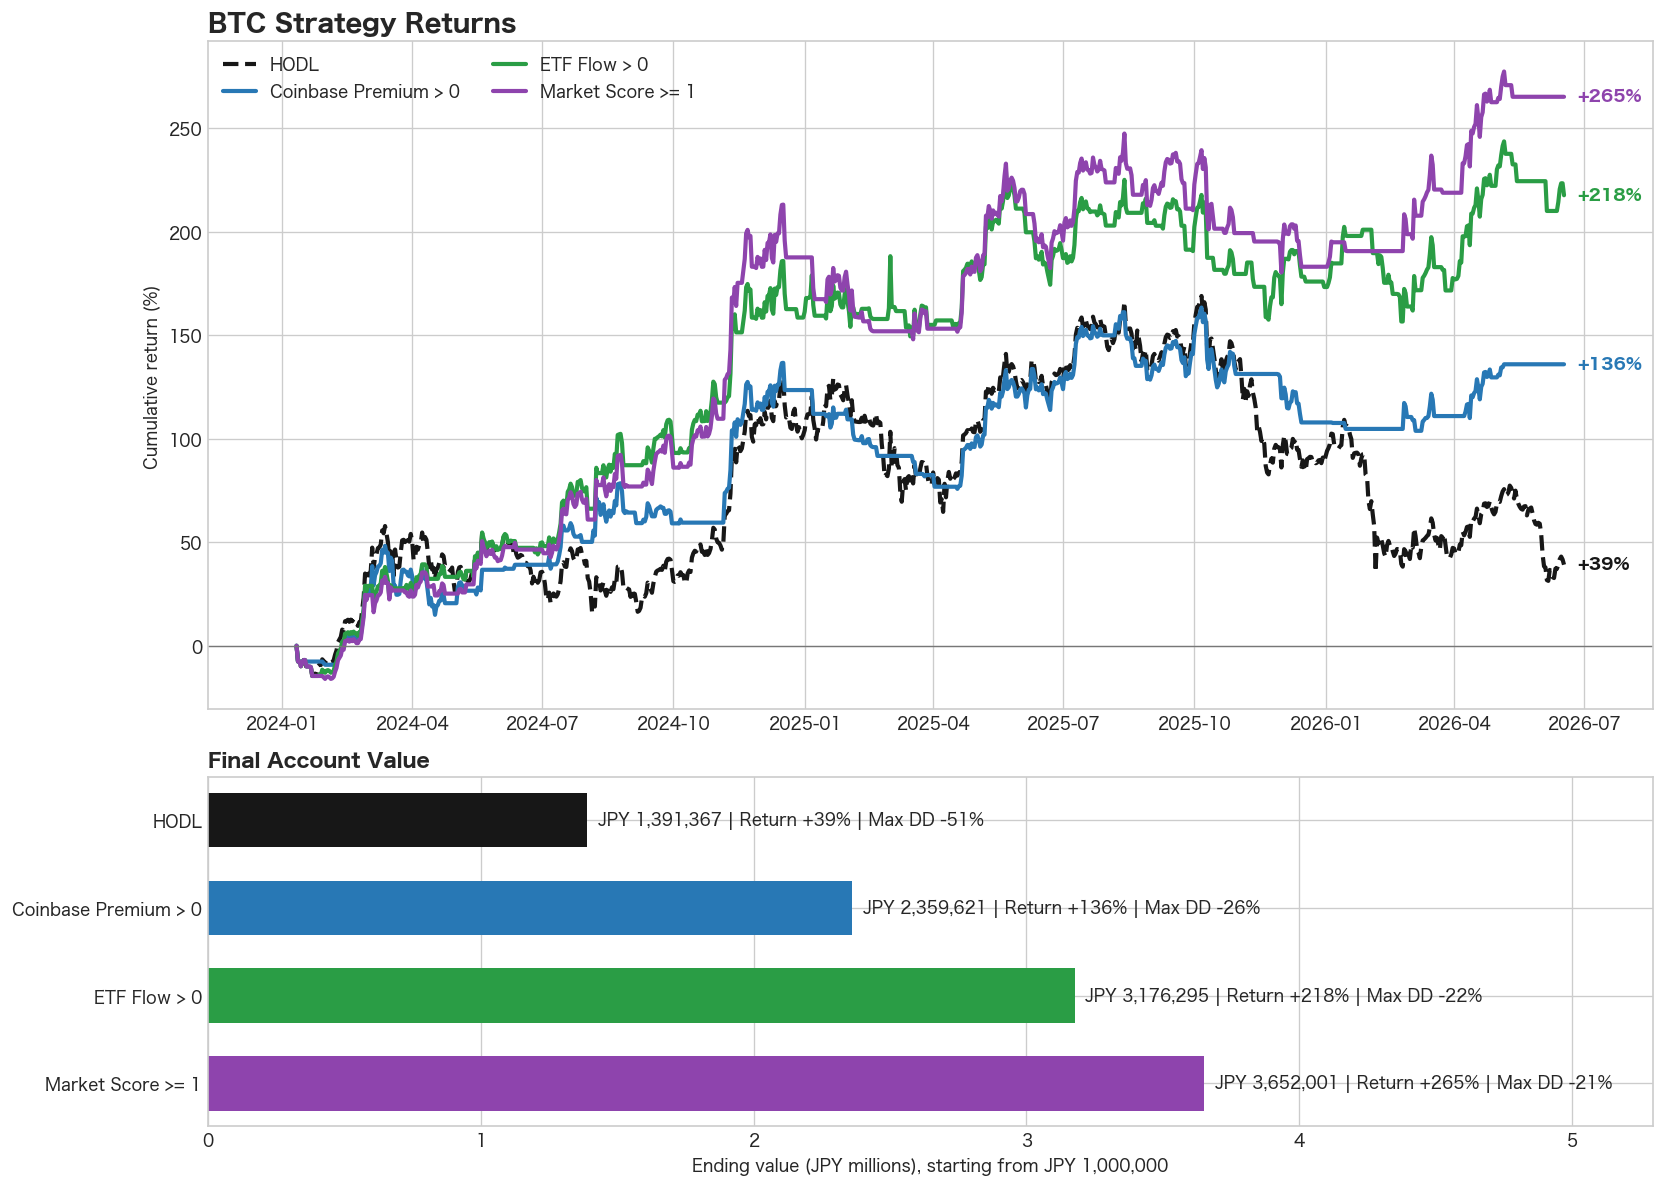

,total_return_pct,max_drawdown_pct,daily_sharpe,calendar_exposure_pct,final_jpy_from_1m
strategy,,,,,
HODL,39.14,-51.18,0.52,100.00,1391367.31
Coinbase Premium > 0,135.96,-25.73,1.22,50.73,2359620.82
ETF Flow > 0,217.63,-22.05,1.51,60.40,3176294.63
Market Score >= 1,265.20,-20.79,1.73,56.69,3652000.71


In [7]:
def performance_stats(returns, position, label):
    returns = pd.Series(returns).fillna(0.0)
    equity = (1.0 + returns).cumprod()
    drawdown = equity / equity.cummax() - 1.0
    std = returns.std()
    sharpe = returns.mean() / std * np.sqrt(365) if std > 0 else np.nan
    return {
        "strategy": label,
        "total_return_pct": (equity.iloc[-1] - 1.0) * 100,
        "max_drawdown_pct": drawdown.min() * 100,
        "daily_sharpe": sharpe,
        "calendar_exposure_pct": pd.Series(position).mean() * 100,
        "final_jpy_from_1m": equity.iloc[-1] * 1_000_000,
    }

main_rules = ["HODL", "Coinbase Premium > 0", "ETF Flow > 0", "Market Score >= 1"]
metrics = pd.DataFrame(
    [performance_stats(daily_returns[r], daily_positions[r], r) for r in main_rules]
).set_index("strategy")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2.2, 1.15]})

ax = axes[0]
for rule in main_rules:
    cumulative_pct = (daily_equity[rule] - 1.0) * 100
    ax.plot(
        cumulative_pct.index,
        cumulative_pct,
        color=COLORS[rule],
        linestyle="--" if rule == "HODL" else "-",
        lw=2.5,
        label=rule,
    )
    ax.annotate(
        f"{cumulative_pct.iloc[-1]:+.0f}%",
        xy=(cumulative_pct.index[-1], cumulative_pct.iloc[-1]),
        xytext=(8, 0), textcoords="offset points",
        color=COLORS[rule], fontweight="bold", va="center",
    )
ax.axhline(0, color="#777777", lw=0.8)
ax.set_title("BTC Strategy Returns", loc="left", fontsize=15, fontweight="bold")
ax.set_ylabel("Cumulative return (%)")
ax.legend(loc="upper left", ncol=2)
ax.margins(x=0.07)

ax = axes[1]
y = np.arange(len(main_rules))
ending_millions = metrics.loc[main_rules, "final_jpy_from_1m"].values / 1e6
bars = ax.barh(y, ending_millions, color=[COLORS[r] for r in main_rules], height=0.62)
ax.set_yticks(y, main_rules)
ax.invert_yaxis()
ax.set_xlabel("Ending value (JPY millions), starting from JPY 1,000,000")
ax.set_title("Final Account Value", loc="left", fontweight="bold")
for bar, rule in zip(bars, main_rules):
    row = metrics.loc[rule]
    ax.text(
        bar.get_width() + 0.04,
        bar.get_y() + bar.get_height() / 2,
        f"JPY {row['final_jpy_from_1m']:,.0f} | Return {row['total_return_pct']:+.0f}% | Max DD {row['max_drawdown_pct']:.0f}%",
        va="center", fontsize=10,
    )
ax.set_xlim(0, ending_millions.max() * 1.45)

fig.tight_layout()
fig.savefig(OUT_DIR / "03_main_strategy_return.png", bbox_inches="tight")
plt.show()
display(metrics.round(2))

* Market Score戦略は+265%で、HODLの+39%を大きく上回りました。
* 最大下落率も-21%程度で、HODLの-51%より小さくなりました。

## 7. 年別に見る

全期間の数字だけでは、特定の相場に依存している可能性を見落とします。年ごとの複利リターンを分けて確認します。

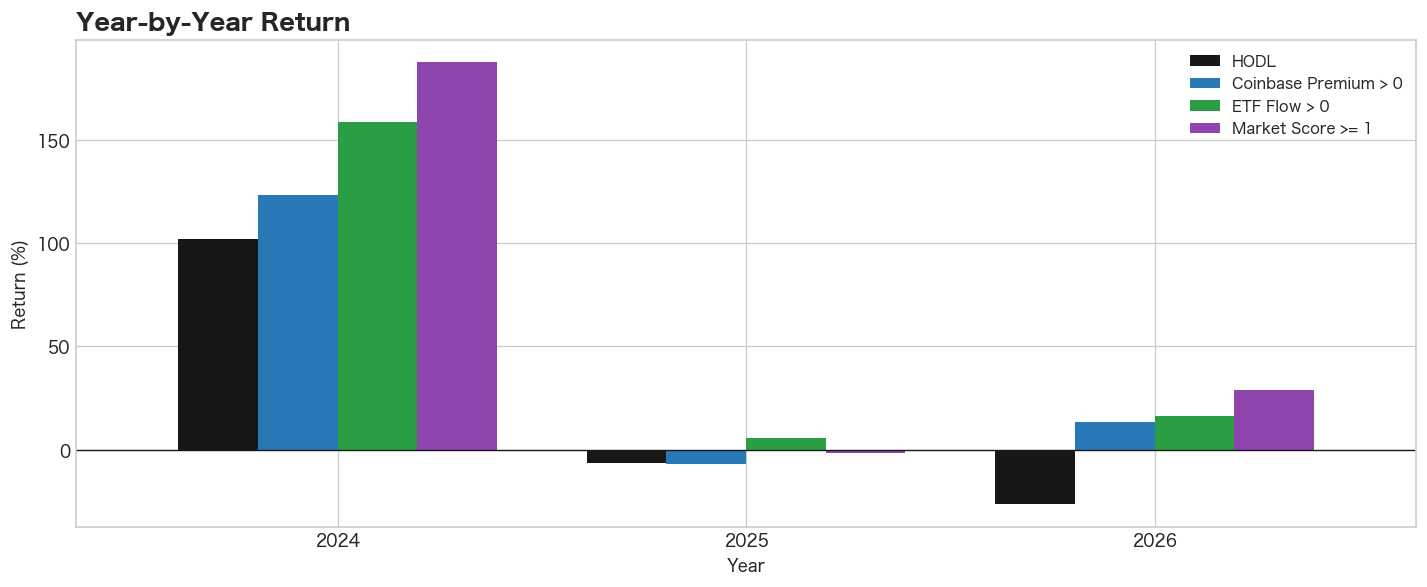

,HODL,Coinbase Premium > 0,ETF Flow > 0,Market Score >= 1
date,,,,
2024,101.9,123.5,158.5,187.6
2025,-6.4,-7.0,5.7,-1.6
2026,-26.4,13.5,16.2,29.0


In [8]:
yearly = {}
for rule in main_rules:
    yearly[rule] = daily_returns[rule].groupby(daily_returns.index.year).apply(lambda s: (1.0 + s).prod() - 1.0) * 100
yearly = pd.DataFrame(yearly)

ax = yearly.plot(kind="bar", figsize=(12, 5), color=[COLORS[r] for r in main_rules], width=0.78)
ax.axhline(0, color="#171717", lw=0.8)
ax.set_title("Year-by-Year Return", loc="left", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Return (%)")
ax.legend(loc="best", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_yearly_return.png", bbox_inches="tight")
plt.show()
display(yearly.round(1))

* Market Score戦略は2024年と2026年に好成績でしたが、2025年は-1.6%でした。
* どの相場でも必ず利益が出るわけではありません。

## 8. スコアの利益は何から来ているか

ETF FlowとCoinbase Premiumを4状態に分けます。

```text
ETF+ / Premium+
ETF+ / Premium-
ETF- / Premium+
ETF- / Premium-
```

ここでは、スコアの高成績が本当に複数指標の組み合わせによるものか、それともETF Flowが主因なのかを確認します。

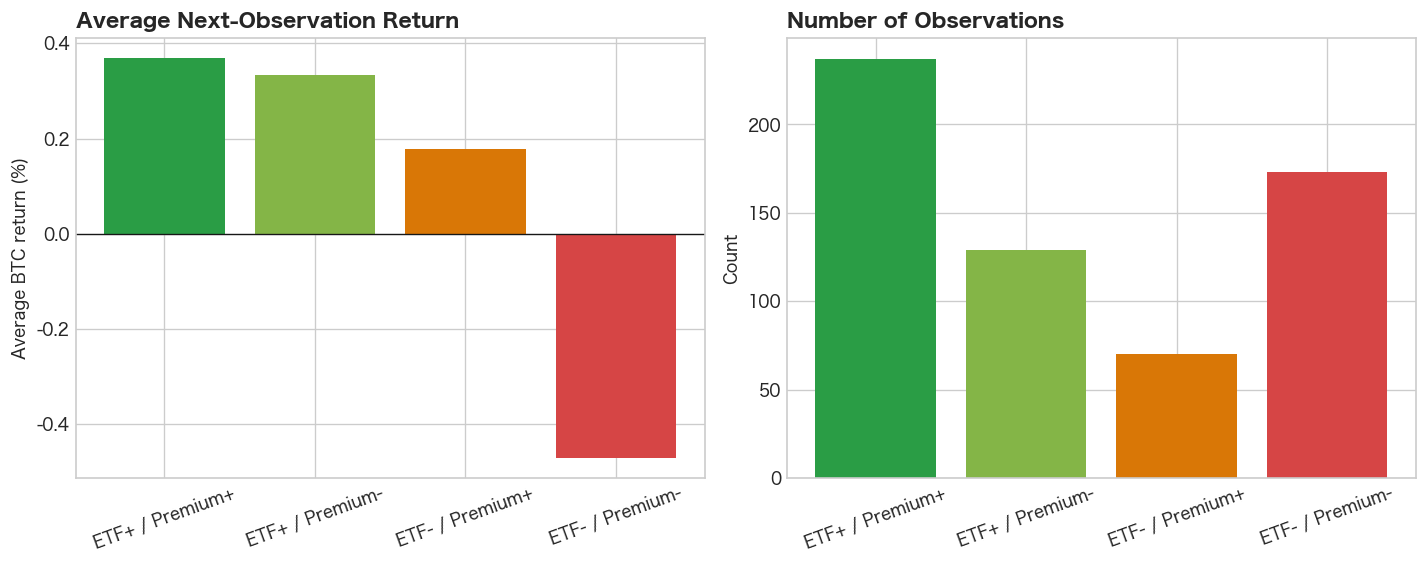

,count,avg_return_pct,win_rate_pct
flow_premium_bucket,,,
ETF+ / Premium+,237,0.37,54.85
ETF+ / Premium-,129,0.33,49.61
ETF- / Premium+,70,0.18,45.71
ETF- / Premium-,173,-0.47,45.09


In [9]:
obs["etf_sign"] = np.where(obs["total_flow_usd"] > 0, "+", "-")
obs["premium_sign"] = np.where(obs["premium_spot_bps"] > 0, "+", "-")
obs["flow_premium_bucket"] = "ETF" + obs["etf_sign"] + " / Premium" + obs["premium_sign"]
bucket_order = ["ETF+ / Premium+", "ETF+ / Premium-", "ETF- / Premium+", "ETF- / Premium-"]

decomp = (
    obs.dropna(subset=["next_observation_return"])
    .groupby("flow_premium_bucket")["next_observation_return"]
    .agg(["count", "mean", lambda s: (s > 0).mean()])
    .rename(columns={"<lambda_0>": "win_rate"})
    .reindex(bucket_order)
)
decomp["avg_return_pct"] = decomp["mean"] * 100
decomp["win_rate_pct"] = decomp["win_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
colors = ["#2a9d45", "#84b547", "#d97706", "#d64545"]
axes[0].bar(decomp.index, decomp["avg_return_pct"], color=colors)
axes[0].axhline(0, color="#171717", lw=0.8)
axes[0].set_title("Average Next-Observation Return", loc="left", fontweight="bold")
axes[0].set_ylabel("Average BTC return (%)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(decomp.index, decomp["count"], color=colors)
axes[1].set_title("Number of Observations", loc="left", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
fig.savefig(OUT_DIR / "05_etf_premium_decomposition.png", bbox_inches="tight")
plt.show()
display(decomp[["count", "avg_return_pct", "win_rate_pct"]].round(2))

* ETF Flowがプラスなら、Coinbase Premiumがマイナスでも次回の平均リターンはプラスでした。
* 今回の成績は、主にETF Flowによって生まれた可能性があります。

## 9. ETF Flowには連続性があるか

ETF Flowがプラスになった後、次の観測でもプラスになりやすいかを確認します。この連続性が前回のFlowを市場環境として使う根拠候補になります。

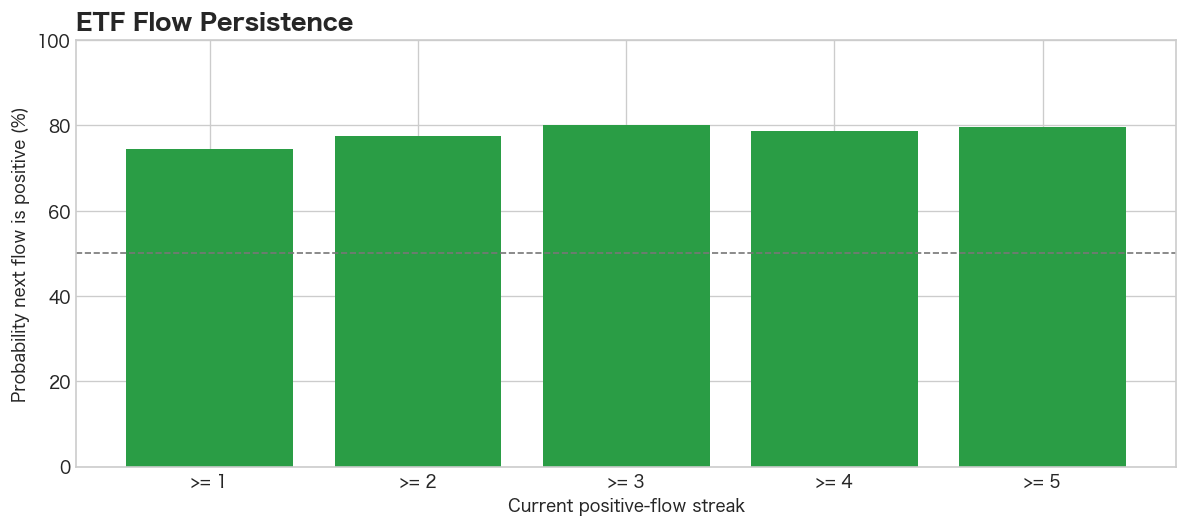

,observations,next_flow_positive_pct,avg_next_btc_return_pct
current_positive_streak,,,
>= 1,366,74.52,0.36
>= 2,272,77.57,0.37
>= 3,211,80.09,0.35
>= 4,169,78.70,0.28
>= 5,133,79.70,0.10


In [10]:
positive = obs["total_flow_usd"] > 0
streak = positive.astype(int).groupby((~positive).cumsum()).cumsum()
next_positive = positive.shift(-1)

persistence_rows = []
for threshold in range(1, 6):
    mask = streak >= threshold
    persistence_rows.append(
        {
            "current_positive_streak": f">= {threshold}",
            "observations": int(mask.sum()),
            "next_flow_positive_pct": next_positive[mask].mean() * 100,
            "avg_next_btc_return_pct": obs.loc[mask, "next_observation_return"].mean() * 100,
        }
    )
persistence = pd.DataFrame(persistence_rows).set_index("current_positive_streak")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(persistence.index, persistence["next_flow_positive_pct"], color="#2a9d45")
ax.axhline(50, color="#777777", lw=1.0, linestyle="--")
ax.set_ylim(0, 100)
ax.set_title("ETF Flow Persistence", loc="left", fontsize=14, fontweight="bold")
ax.set_ylabel("Probability next flow is positive (%)")
ax.set_xlabel("Current positive-flow streak")
fig.tight_layout()
fig.savefig(OUT_DIR / "06_etf_flow_persistence.png", bbox_inches="tight")
plt.show()
display(persistence.round(2))

* ETF Flowがプラスになると、次回もプラスになる確率は約75〜80%でした。
* ただし、連続回数が増えてもBTCの平均リターンは大きくなっていません。

## 10. 最重要: ETF Flowの公表時刻

紫線の高い成績は、ETF Flow最終値を日付`t`のBTC終値時点で利用できたと仮定しています。

しかし、実際にETF Flowが判明する時刻が終値より遅ければ、その価格では取引できません。そこで、スコアを1回分遅らせた保守的な比較を行います。

```text
即時利用仮定版: 日付tのFlowを、日付tの終値から使う
1観測日遅延版: 日付tのFlowを、次のETF観測日から使う
```

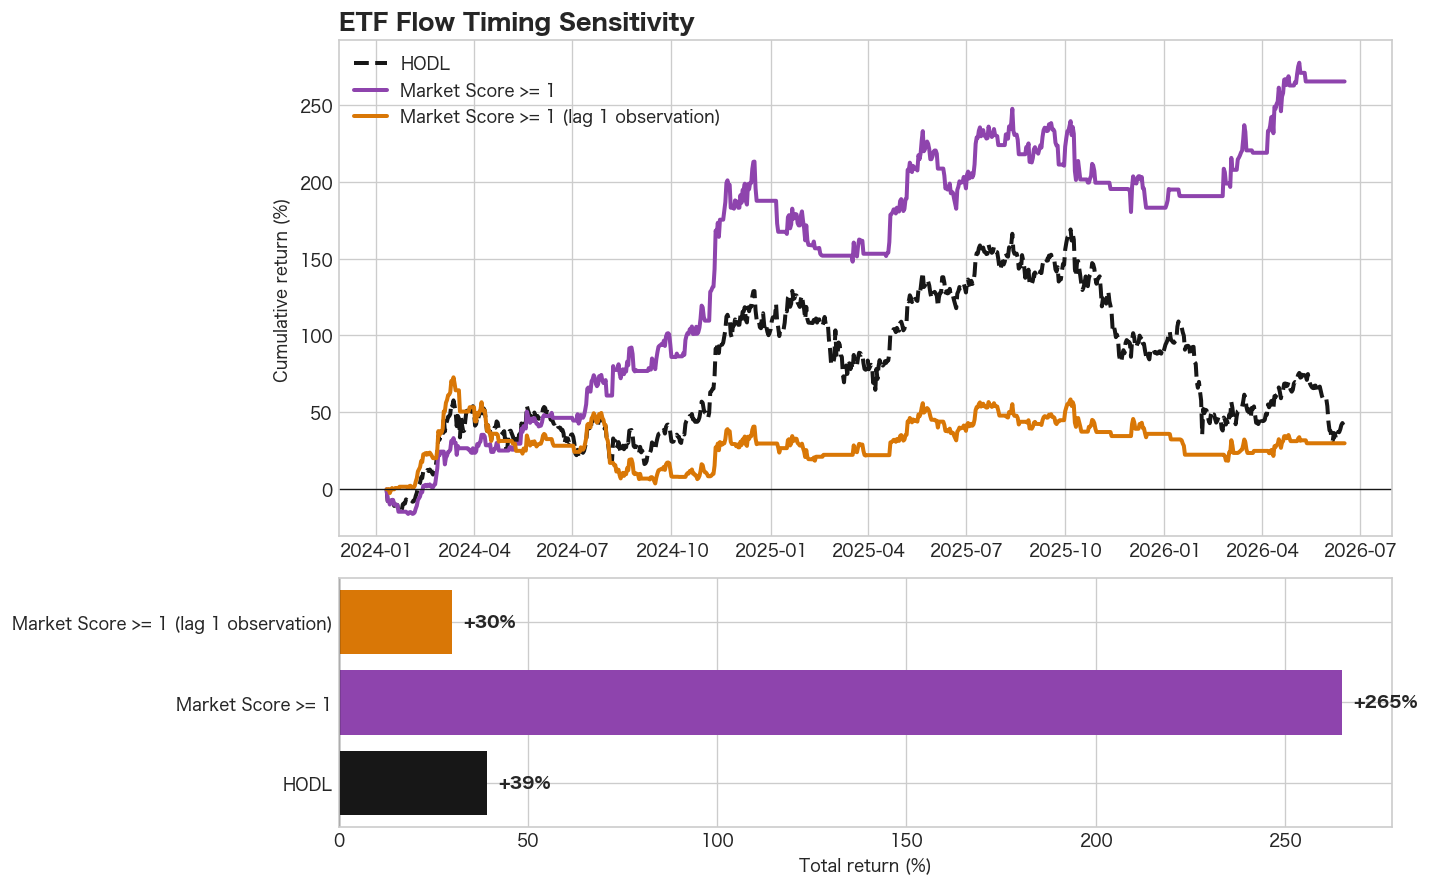

,total_return_pct,max_drawdown_pct,daily_sharpe,calendar_exposure_pct,final_jpy_from_1m
strategy,,,,,
HODL,39.14,-51.18,0.52,100.00,1391367.31
Market Score >= 1,265.20,-20.79,1.73,56.69,3652000.71
Market Score >= 1 (lag 1 observation),29.91,-39.94,0.49,55.01,1299088.82


In [11]:
timing_rules = ["HODL", "Market Score >= 1", "Market Score >= 1 (lag 1 observation)"]
timing_metrics = pd.DataFrame(
    [performance_stats(daily_returns[r], daily_positions[r], r) for r in timing_rules]
).set_index("strategy")

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), gridspec_kw={"height_ratios": [2.0, 1.0]})
for rule in timing_rules:
    axes[0].plot(
        daily_equity.index,
        (daily_equity[rule] - 1.0) * 100,
        color=COLORS[rule],
        linestyle="--" if rule == "HODL" else "-",
        lw=2.4,
        label=rule,
    )
axes[0].axhline(0, color="#171717", lw=0.8)
axes[0].set_title("ETF Flow Timing Sensitivity", loc="left", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Cumulative return (%)")
axes[0].legend(loc="upper left")

bars = axes[1].barh(
    timing_metrics.index,
    timing_metrics["total_return_pct"],
    color=[COLORS[r] for r in timing_metrics.index],
)
axes[1].axvline(0, color="#171717", lw=0.8)
axes[1].set_xlabel("Total return (%)")
for bar, value in zip(bars, timing_metrics["total_return_pct"]):
    axes[1].text(value + 3, bar.get_y() + bar.get_height() / 2, f"{value:+.0f}%", va="center", fontweight="bold")

fig.tight_layout()
fig.savefig(OUT_DIR / "07_timing_sensitivity.png", bbox_inches="tight")
plt.show()
display(timing_metrics.round(2))

* スコアを1観測日遅らせると、リターンは+265%から+30%まで低下しました。
* つまり、好成績はETF Flowをいつ取得できるかに強く依存しており、現状のまま実運用できるとはいえません。

## 11. 参考: 売買コストを入れる

主結果は手数料・スリッページなしです。ここでは、ポジションの切り替え時に片道コストを差し引く簡易ストレスを確認します。

ETF公表時刻の問題に比べれば影響は小さい可能性がありますが、配信資料ではグロス結果とコスト込み結果を区別します。

In [12]:
score_position = daily_positions["Market Score >= 1"]
turnover = score_position.diff().abs().fillna(score_position.iloc[0])
cost_rows = []
for cost_bps in [0, 5, 10, 20]:
    net_return = daily_returns["Market Score >= 1"] - turnover * cost_bps / 10_000
    row = performance_stats(net_return, score_position, f"{cost_bps} bps per position change")
    cost_rows.append(row)
cost_table = pd.DataFrame(cost_rows).set_index("strategy")
display(cost_table[["total_return_pct", "max_drawdown_pct", "daily_sharpe", "final_jpy_from_1m"]].round(2))

,total_return_pct,max_drawdown_pct,daily_sharpe,final_jpy_from_1m
strategy,,,,
0 bps per position change,265.20,-20.79,1.73,3652000.71
5 bps per position change,243.62,-21.19,1.66,3436214.66
10 bps per position change,223.31,-21.58,1.59,3233080.37
20 bps per position change,186.19,-22.37,1.44,2861865.54


## 12. ここまでのまとめ

- BTCの上下を直接予測するのではなく、ロングを許可する市場環境フィルターを作った。
- 主役は`Market Score >= 1`。ETF Flow、Coinbase Premium、ETF Flow 5観測日平均、Fundingを採点する。
- 固定された過去データでは、HODLより高いリターンと小さいドローダウンになった。
- エッジの大半はETF Flow由来で、Coinbase Premiumは補助的な確認指標だった。
- ETF Flowには連続性があるが、Flowの連続性だけで価格予測力を証明したことにはならない。
- 1観測日遅延させると成績が大きく低下する。高成績はETF Flowの利用可能時刻に強く依存する。
- 現段階では「有望な研究ロジック」であり、完成BOTとして採用できる状態ではない。

### 次の検証候補

1. ETF Flowが実際に取得可能になったtimestampを保存する。
2. 公表後の最初の実行可能価格でエントリーする。
3. 同じルールを変更せず、フォワードテストする。
4. 手数料・スリッページを反映する。
5. その後にGEX、OI、VIX、DXY、米10年金利の追加価値を確認する。

---
## 免責事項

* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。